In [54]:
!pip install pyspark


# IST3134 Group Assignment – Spotify Big Data Analysis

## Project focus
This notebook analyses **114,000 Spotify tracks** by genre and investigates how audio characteristics such as danceability, energy, valence, tempo and loudness are related to track popularity.

Two implementations are used:

1. **PySpark** – the Big Data/distributed processing approach.
2. **Pandas** – the non-Big-Data/single-machine comparison approach.

The main Spark operation is `groupBy("track_genre").agg(...)`. Conceptually, this follows the MapReduce pattern:

**Map → Shuffle/Group by key → Reduce/Aggregate**

For this project, the key is `track_genre`, and the reduce stage calculates average audio features, average popularity and track counts.


In [55]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg,
    round as spark_round,
    count,
    col,
    isnan,
    when
)

os.makedirs("output", exist_ok=True)

FEATURES = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness"
]

CHECK_COLS = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo",
    "track_genre"
]

NUMERIC_COLS = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo"
]

DATA_PATH = "/content/dataset.csv"


## 1. Start Spark and load the dataset

Spark session startup is measured separately because it is a one-time framework overhead. It is **not included in the fair Spark-vs-Pandas computation comparison**.


In [56]:
session_start = time.time()
spark = SparkSession.builder.appName("SpotifyBigDataAnalysis").getOrCreate()
spark.sparkContext.setLogLevel("WARN")
session_startup_time = time.time() - session_start

print(f"Spark session startup time: {session_startup_time:.2f} seconds")
print("(One-time startup cost; excluded from the fair computation comparison.)")

df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True,
    quote='"',
    escape='"',
    multiLine=True
)

# Standardise numerical columns before caching so the cached DataFrame
# contains the version actually used in the analysis.
for c in NUMERIC_COLS:
    df = df.withColumn(c, col(c).cast("double"))

df.cache()

total_rows = df.count()
total_columns = len(df.columns)

print("\n=== Dataset Overview ===")
print(f"Rows: {total_rows:,}")
print(f"Columns: {total_columns}")
print("Columns:")
print(df.columns)

print("\n=== Schema ===")
df.printSchema()

print("\n=== First 5 Records ===")
df.show(5, truncate=False)


Spark session startup time: 0.00 seconds
(One-time startup cost; excluded from the fair computation comparison.)

=== Dataset Overview ===
Rows: 114,000
Columns: 21
Columns:
['_c0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

=== Schema ===
root
 |-- _c0: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: double (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- explicit: boolean (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechines

## 2. Data quality checks

The dataset is checked for missing values and repeated `track_id` values before the main analysis.

Duplicate IDs are **reported rather than automatically removed**, because the same track may legitimately appear with different genre classifications. This avoids changing the dataset without justification.


In [57]:
print("=== Missing Value Check (PySpark) ===")

missing_counts = df.select([
    count(
        when(
            col(c).isNull() | (isnan(col(c)) if c != "track_genre" else col(c).isNull()),
            1
        )
    ).alias(c)
    for c in CHECK_COLS
])

missing_counts.show()
missing_counts.coalesce(1).write.mode("overwrite").option("header", True).csv(
    "output/missing_values_spark"
)

print("=== Duplicate track_id Check (PySpark) ===")

total_count = df.count()
missing_track_ids = df.filter(col("track_id").isNull()).count()

duplicate_groups = (
    df.filter(col("track_id").isNotNull())
      .groupBy("track_id")
      .count()
      .filter(col("count") > 1)
)

duplicate_extra_rows = (
    duplicate_groups
    .selectExpr("coalesce(sum(count - 1), 0) AS duplicate_extra_rows")
    .collect()[0]["duplicate_extra_rows"]
)

distinct_track_ids = (
    df.filter(col("track_id").isNotNull())
      .select("track_id")
      .distinct()
      .count()
)

print(f"Total rows: {total_count:,}")
print(f"Distinct non-null track_id values: {distinct_track_ids:,}")
print(f"Missing track_id values: {missing_track_ids:,}")
print(f"Repeated track_id rows beyond the first occurrence: {int(duplicate_extra_rows):,}")

if int(duplicate_extra_rows) > 0:
    print("Note: repeated track IDs are reported and retained for analysis.")
else:
    print("No repeated track_id values found.")


=== Missing Value Check (PySpark) ===
+----------+------------+------+--------+-------+-----+-----------+
|popularity|danceability|energy|loudness|valence|tempo|track_genre|
+----------+------------+------+--------+-------+-----+-----------+
|         0|           0|     0|       0|      0|    0|          0|
+----------+------------+------+--------+-------+-----+-----------+

=== Duplicate track_id Check (PySpark) ===
Total rows: 114,000
Distinct non-null track_id values: 89,741
Missing track_id values: 0
Repeated track_id rows beyond the first occurrence: 24,259
Note: repeated track IDs are reported and retained for analysis.


## 3. PySpark Big Data analysis

### MapReduce interpretation

For the genre-profile analysis:

- **Map:** each Spotify record is associated with its `track_genre` key and relevant numeric values.
- **Shuffle/Group:** Spark groups records with the same `track_genre`.
- **Reduce:** Spark calculates averages and counts for each genre.

This allows the large collection of track records to be summarised by genre using Spark's distributed DataFrame operations.


In [58]:
spark_compute_start = time.time()

# Genre-level aggregation: the main Big Data analytical operation.
genre_profile = (
    df.groupBy("track_genre")
      .agg(
          spark_round(avg("danceability"), 3).alias("avg_danceability"),
          spark_round(avg("energy"), 3).alias("avg_energy"),
          spark_round(avg("valence"), 3).alias("avg_valence"),
          spark_round(avg("tempo"), 2).alias("avg_tempo"),
          spark_round(avg("popularity"), 2).alias("avg_popularity"),
          count("*").alias("track_count"),
      )
      .orderBy("avg_popularity", ascending=False)
)

print("=== Top 25 Genres by Average Popularity ===")
genre_profile.show(25, truncate=False)

genre_profile.coalesce(1).write.mode("overwrite").option("header", True).csv(
    "output/genre_profile"
)

print("=== Correlation with Popularity ===")
correlations = []

for feature in FEATURES:
    corr = df.stat.corr(feature, "popularity")
    correlations.append((feature, corr))
    print(f"{feature:15s} -> corr with popularity: {corr:.4f}")

with open("output/correlations.txt", "w") as f:
    for feature, corr in correlations:
        f.write(f"{feature}: {corr:.4f}\n")

# Define high popularity as the top 25% of tracks using the 75th percentile.
threshold = df.approxQuantile("popularity", [0.75], 0.01)[0]
print(f"\nPopularity threshold (75th percentile): {threshold:.2f}")

high_pop = df.filter(df.popularity >= threshold)
low_pop = df.filter(df.popularity < threshold)

print("\n=== High-Popularity Group Averages ===")
high_pop.agg(
    spark_round(avg("danceability"), 3).alias("avg_danceability"),
    spark_round(avg("energy"), 3).alias("avg_energy"),
    spark_round(avg("valence"), 3).alias("avg_valence"),
).show()

print("=== Low-Popularity Group Averages ===")
low_pop.agg(
    spark_round(avg("danceability"), 3).alias("avg_danceability"),
    spark_round(avg("energy"), 3).alias("avg_energy"),
    spark_round(avg("valence"), 3).alias("avg_valence"),
).show()

spark_compute_elapsed = time.time() - spark_compute_start

print(f"\nSpark COMPUTATION time (fair): {spark_compute_elapsed:.2f} seconds")
print(f"Spark session startup time: {session_startup_time:.2f} seconds")
print(f"Spark TOTAL wall-clock time: {session_startup_time + spark_compute_elapsed:.2f} seconds")

with open("output/spark_runtime.txt", "w") as f:
    f.write(f"Spark session startup time: {session_startup_time:.2f} seconds\n")
    f.write(f"Spark computation time (fair): {spark_compute_elapsed:.2f} seconds\n")
    f.write(f"Spark total wall-clock time: {session_startup_time + spark_compute_elapsed:.2f} seconds\n")
    f.write(f"Rows processed: {total_rows}\n")


=== Top 25 Genres by Average Popularity ===
+-----------------+----------------+----------+-----------+---------+--------------+-----------+
|track_genre      |avg_danceability|avg_energy|avg_valence|avg_tempo|avg_popularity|track_count|
+-----------------+----------------+----------+-----------+---------+--------------+-----------+
|pop-film         |0.597           |0.605     |0.529      |117.26   |59.28         |1000       |
|k-pop            |0.648           |0.676     |0.557      |119.24   |56.9          |1000       |
|chill            |0.664           |0.427     |0.404      |115.48   |53.65         |1000       |
|sad              |0.692           |0.462     |0.422      |119.06   |52.38         |1000       |
|grunge           |0.457           |0.803     |0.4        |129.35   |49.59         |1000       |
|indian           |0.592           |0.567     |0.463      |116.14   |49.54         |1000       |
|anime            |0.537           |0.674     |0.434      |123.53   |48.77         

## 4. Pandas implementation for comparison

The Pandas implementation performs the **same main analytical workload** as PySpark:

1. Genre-level aggregation.
2. Correlation with popularity.
3. 75th-percentile high/low popularity comparison.

Only the computation stage is timed because the data are loaded before the timer starts. This makes the comparison more meaningful.


In [59]:
pdf = pd.read_csv(DATA_PATH)

for c in NUMERIC_COLS:
    pdf[c] = pd.to_numeric(pdf[c], errors="coerce")

total_count_pd = len(pdf)

print("=== Pandas Dataset Overview ===")
print(f"Rows: {len(pdf):,}")
print(f"Columns: {len(pdf.columns)}")
print(pdf.columns.tolist())

print("\n=== Missing Value Check (Pandas) ===")
missing_counts_pd = pdf[CHECK_COLS].isnull().sum()
print(missing_counts_pd)
missing_counts_pd.to_csv("output/missing_values_pandas.csv")

print("\n=== Duplicate track_id Check (Pandas) ===")
missing_track_ids_pd = pdf["track_id"].isnull().sum()
duplicate_extra_rows_pd = (
    pdf.loc[pdf["track_id"].notna(), "track_id"]
       .duplicated(keep="first")
       .sum()
)

print(f"Total rows: {total_count_pd:,}")
print(f"Distinct non-null track_id values: {pdf['track_id'].dropna().nunique():,}")
print(f"Missing track_id values: {missing_track_ids_pd:,}")
print(f"Repeated track_id rows beyond the first occurrence: {duplicate_extra_rows_pd:,}")


=== Pandas Dataset Overview ===
Rows: 114,000
Columns: 21
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

=== Missing Value Check (Pandas) ===
popularity      0
danceability    0
energy          0
loudness        0
valence         0
tempo           0
track_genre     0
dtype: int64

=== Duplicate track_id Check (Pandas) ===
Total rows: 114,000
Distinct non-null track_id values: 89,741
Missing track_id values: 0
Repeated track_id rows beyond the first occurrence: 24,259


In [60]:
pandas_compute_start = time.time()

genre_profile_pd = (
    pdf.groupby("track_genre")
       .agg(
           avg_danceability=("danceability", "mean"),
           avg_energy=("energy", "mean"),
           avg_valence=("valence", "mean"),
           avg_tempo=("tempo", "mean"),
           avg_popularity=("popularity", "mean"),
           track_count=("popularity", "count"),
       )
       .round(3)
       .sort_values("avg_popularity", ascending=False)
)

print("=== Top 25 Genres by Average Popularity (Pandas) ===")
print(genre_profile_pd.head(25))
genre_profile_pd.to_csv("output/genre_profile_pandas.csv")

print("\n=== Correlation with Popularity (Pandas) ===")
correlations_pd = {}

for feature in FEATURES:
    corr = pdf[feature].corr(pdf["popularity"])
    correlations_pd[feature] = corr
    print(f"{feature:15s} -> corr with popularity: {corr:.4f}")

with open("output/correlations_pandas.txt", "w") as f:
    for feature, corr in correlations_pd.items():
        f.write(f"{feature}: {corr:.4f}\n")

threshold_pd = pdf["popularity"].quantile(0.75)
print(f"\nPopularity threshold (75th percentile): {threshold_pd:.2f}")

high_pop_pd = pdf[pdf["popularity"] >= threshold_pd]
low_pop_pd = pdf[pdf["popularity"] < threshold_pd]

print("\n=== High-Popularity Group Averages (Pandas) ===")
print(high_pop_pd[["danceability", "energy", "valence"]].mean().round(3))

print("\n=== Low-Popularity Group Averages (Pandas) ===")
print(low_pop_pd[["danceability", "energy", "valence"]].mean().round(3))

pandas_compute_elapsed = time.time() - pandas_compute_start

print(f"\nPandas COMPUTATION time (fair): {pandas_compute_elapsed:.2f} seconds")

with open("output/pandas_runtime.txt", "w") as f:
    f.write(f"Pandas computation time (fair): {pandas_compute_elapsed:.2f} seconds\n")
    f.write(f"Rows processed: {total_count_pd}\n")


=== Top 25 Genres by Average Popularity (Pandas) ===
                   avg_danceability  avg_energy  avg_valence  avg_tempo  \
track_genre                                                               
pop-film                      0.597       0.605        0.529    117.257   
k-pop                         0.648       0.676        0.557    119.244   
chill                         0.664       0.427        0.404    115.479   
sad                           0.692       0.462        0.422    119.065   
grunge                        0.457       0.803        0.400    129.349   
indian                        0.592       0.567        0.463    116.143   
anime                         0.537       0.674        0.434    123.530   
emo                           0.599       0.670        0.441    126.993   
sertanejo                     0.592       0.710        0.619    127.052   
pop                           0.630       0.606        0.506    120.927   
progressive-house             0.624       0.813

In [61]:
print("\n" + "="*65)
print("PYSPARK vs PANDAS COMPUTATION TIME COMPARISON")
print("(Spark startup time excluded)")
print("="*65)

print(f"PySpark computation time: {spark_compute_elapsed:.2f} seconds")
print(f"Pandas computation time:  {pandas_compute_elapsed:.2f} seconds")
print(f"Spark startup time:       {session_startup_time:.2f} seconds (excluded)")

if spark_compute_elapsed < pandas_compute_elapsed:
    faster = "PySpark"
    ratio = pandas_compute_elapsed / spark_compute_elapsed
else:
    faster = "Pandas"
    ratio = spark_compute_elapsed / pandas_compute_elapsed

print(f"Faster for this dataset: {faster}")
print(f"Approximate runtime ratio: {ratio:.2f}x")

# Check that both implementations processed the same number of rows.
print("\n=== Comparison Consistency Check ===")
print(f"PySpark rows: {total_rows:,}")
print(f"Pandas rows:  {total_count_pd:,}")
print(f"Same row count: {total_rows == total_count_pd}")

if total_rows != total_count_pd:
    raise ValueError("PySpark and Pandas did not process the same number of rows.")



PYSPARK vs PANDAS COMPUTATION TIME COMPARISON
(Spark startup time excluded)
PySpark computation time: 6.37 seconds
Pandas computation time:  0.26 seconds
Spark startup time:       0.00 seconds (excluded)
Faster for this dataset: Pandas
Approximate runtime ratio: 24.87x

=== Comparison Consistency Check ===
PySpark rows: 114,000
Pandas rows:  114,000
Same row count: True


## 5. Visualisations

The charts below support the output-analysis section of the report. Each chart should be discussed using:

**Finding → Interpretation → Implication/Limitation**

Do not only describe what the chart looks like.


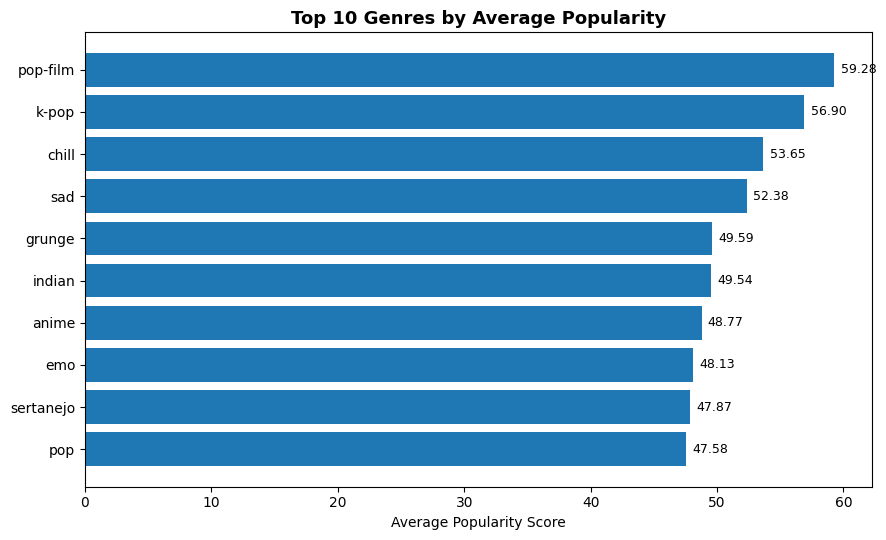

In [62]:
# Chart 1: Top 10 genres by average popularity
top10 = genre_profile_pd.head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top10.index[::-1], top10["avg_popularity"][::-1])
ax.set_xlabel("Average Popularity Score")
ax.set_title("Top 10 Genres by Average Popularity", fontsize=13, fontweight="bold")

for bar, val in zip(bars, top10["avg_popularity"][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("output/chart1_top_genres.png", dpi=150)
plt.show()


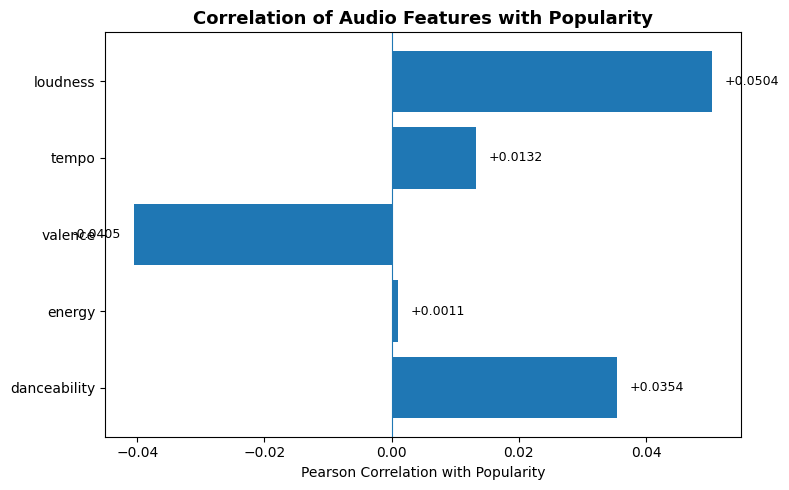

In [63]:
# Chart 2: Correlation of audio features with popularity
feat_labels = list(correlations_pd.keys())
corr_values = list(correlations_pd.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_labels, corr_values)
ax.axvline(0, linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Popularity")
ax.set_title("Correlation of Audio Features with Popularity", fontsize=13, fontweight="bold")

for bar, val in zip(bars, corr_values):
    offset = 0.002 if val >= 0 else -0.002
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2, f"{val:+.4f}",
            va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig("output/chart2_correlations.png", dpi=150)
plt.show()


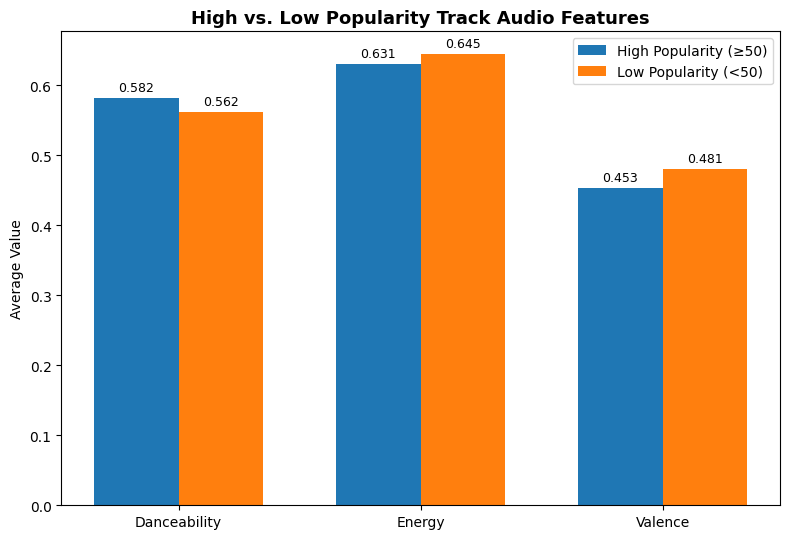

In [64]:
# Chart 3: High vs low popularity audio features
feat3 = ["danceability", "energy", "valence"]
high_vals = high_pop_pd[feat3].mean().round(3)
low_vals = low_pop_pd[feat3].mean().round(3)

x = np.arange(len(feat3))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5.5))
b1 = ax.bar(x - width/2, high_vals, width, label=f"High Popularity (≥{threshold_pd:.0f})")
b2 = ax.bar(x + width/2, low_vals, width, label=f"Low Popularity (<{threshold_pd:.0f})")

ax.set_ylabel("Average Value")
ax.set_title("High vs. Low Popularity Track Audio Features", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in feat3])
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("output/chart3_high_vs_low.png", dpi=150)
plt.show()


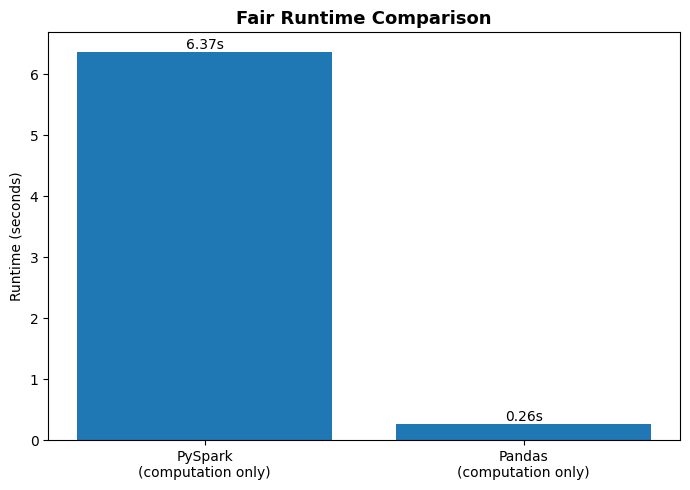

In [65]:
# Chart 4A: Fair computation-only runtime comparison
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["PySpark\n(computation only)", "Pandas\n(computation only)"]
values = [spark_compute_elapsed, pandas_compute_elapsed]

bars = ax.bar(labels, values)
ax.set_ylabel("Runtime (seconds)")
ax.set_title("Fair Runtime Comparison", fontsize=13, fontweight="bold")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.2f}s", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("output/chart4a_fair_runtime.png", dpi=150)
plt.show()


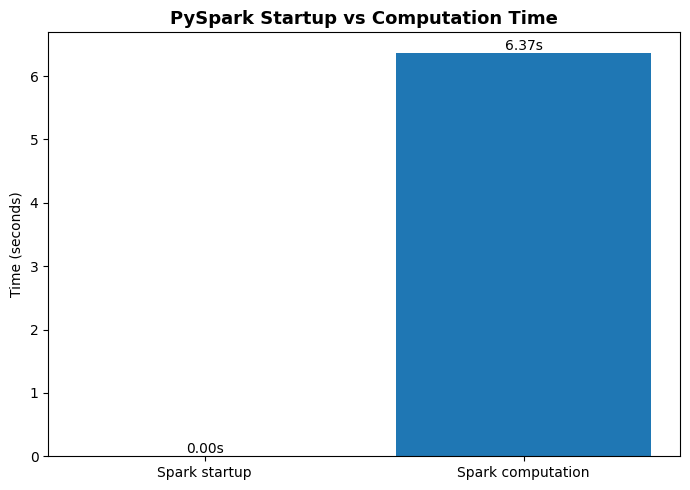

In [66]:
# Chart 4B: Spark startup overhead shown separately
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Spark startup", "Spark computation"]
values = [session_startup_time, spark_compute_elapsed]

bars = ax.bar(labels, values)
ax.set_ylabel("Time (seconds)")
ax.set_title("PySpark Startup vs Computation Time", fontsize=13, fontweight="bold")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.2f}s", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("output/chart4b_spark_overhead.png", dpi=150)
plt.show()


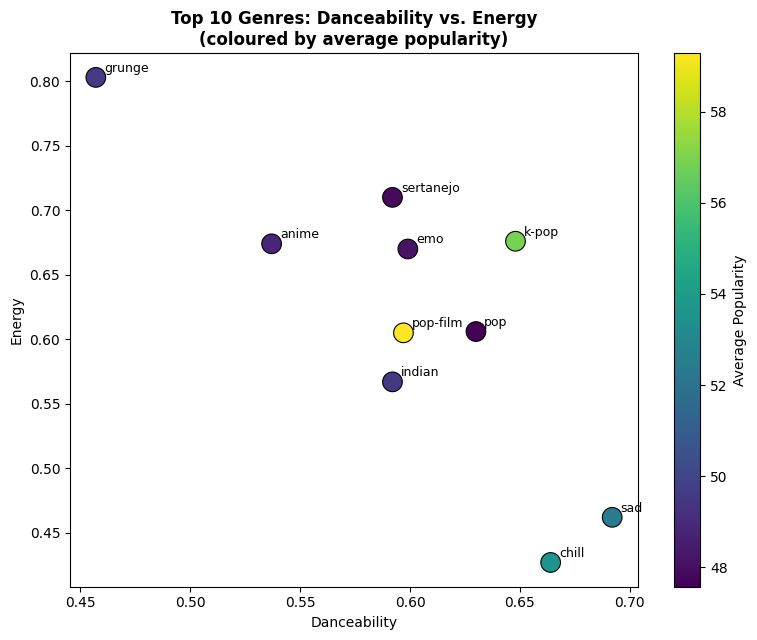

All charts saved to the output/ folder.


In [67]:
# Chart 5: Danceability vs energy for the top 10 genres
fig, ax = plt.subplots(figsize=(8, 6.5))

scatter = ax.scatter(
    top10["avg_danceability"],
    top10["avg_energy"],
    c=top10["avg_popularity"],
    s=200,
    cmap="viridis",
    edgecolors="black",
    linewidth=0.8
)

for genre_name, row in top10.iterrows():
    ax.annotate(
        genre_name,
        (row["avg_danceability"], row["avg_energy"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9
    )

ax.set_xlabel("Danceability")
ax.set_ylabel("Energy")
ax.set_title(
    "Top 10 Genres: Danceability vs. Energy\n(coloured by average popularity)",
    fontsize=12,
    fontweight="bold"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Average Popularity")

plt.tight_layout()
plt.savefig("output/chart5_scatter_genres.png", dpi=150)
plt.show()

print("All charts saved to the output/ folder.")


## 6. Automatic result summary for the report

This cell prints the key results after the notebook has been executed. Use the actual values produced here in the report rather than inventing numbers.


In [68]:
top_genre = genre_profile_pd.index[0]
top_genre_popularity = genre_profile_pd.iloc[0]["avg_popularity"]

strongest_feature = max(correlations_pd, key=lambda x: abs(correlations_pd[x]))
strongest_corr = correlations_pd[strongest_feature]

print("=== KEY FINDINGS ===")
print(f"1. Highest average-popularity genre: {top_genre} ({top_genre_popularity:.2f})")
print(f"2. 75th-percentile popularity threshold: {threshold_pd:.2f}")
print(f"3. Strongest absolute feature-popularity correlation: {strongest_feature} ({strongest_corr:+.4f})")
print(f"4. PySpark computation time: {spark_compute_elapsed:.2f}s")
print(f"5. Pandas computation time: {pandas_compute_elapsed:.2f}s")

print("\nReport reminder:")
print("- Explain what the highest/lowest values mean.")
print("- Explain whether correlations are weak, moderate or strong.")
print("- Do not claim correlation proves causation.")
print("- Discuss why Pandas may be faster for a dataset of this size.")
print("- Explain that Spark's main advantage is scalable/distributed processing.")


=== KEY FINDINGS ===
1. Highest average-popularity genre: pop-film (59.28)
2. 75th-percentile popularity threshold: 50.00
3. Strongest absolute feature-popularity correlation: loudness (+0.0504)
4. PySpark computation time: 6.37s
5. Pandas computation time: 0.26s

Report reminder:
- Explain what the highest/lowest values mean.
- Explain whether correlations are weak, moderate or strong.
- Do not claim correlation proves causation.
- Discuss why Pandas may be faster for a dataset of this size.
- Explain that Spark's main advantage is scalable/distributed processing.
